In [32]:
import importlib
import importlib.util
from pathlib import Path
import pandas as pd

if importlib.util.find_spec("google.colab") is not None:
    drive = importlib.import_module("google.colab.drive")
    drive.mount("/content/drive")
    data_path = Path("/content/drive/MyDrive/Data/drug.csv")
else:
    data_path = Path("Data/drug.csv")

drug_df = pd.read_csv(data_path)
drug_df = drug_df.sample(frac=1, random_state=42)
drug_df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
95,36,M,LOW,NORMAL,11.424,drugX
15,16,F,HIGH,NORMAL,15.516,DrugY
30,18,F,NORMAL,NORMAL,8.750,drugX


In [13]:
from sklearn.model_selection import train_test_split

X = drug_df.drop("Drug", axis=1).values
y = drug_df.Drug.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=125
)

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

cat_col = [1,2,3]
num_col = [0,4]

transform = ColumnTransformer(
    [
        ("encoder", OrdinalEncoder(), cat_col),
        ("num_imputer", SimpleImputer(strategy="median"), num_col),
        ("num_scaler", StandardScaler(), num_col),
    ]
)
pipe = Pipeline(
    steps=[
        ("preprocessing", transform),
        ("model", RandomForestClassifier(n_estimators=100, random_state=125)),
    ]
)
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('encoder', OrdinalEncoder(),
                                                  [1, 2, 3]),
                                                 ('num_imputer',
                                                  SimpleImputer(strategy='median'),
                                                  [0, 4]),
                                                 ('num_scaler',
                                                  StandardScaler(), [0, 4])])),
                ('model', RandomForestClassifier(random_state=125))])

In [15]:
from sklearn.metrics import accuracy_score, f1_score

predictions = pipe.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average="macro")

print("Accuracy:", str(round(accuracy, 2) * 100) + "%", "F1:", round(f1, 2))

Accuracy: 97.0% F1: 0.94


In [16]:
from pathlib import Path
Path("result").mkdir(parents=True, exist_ok=True)
with open("result/metrics.txt", "w") as outfile:
    outfile.write(f"\nAccuracy = {round(accuracy, 2)}, F1 Score = {round(f1, 2)}.")

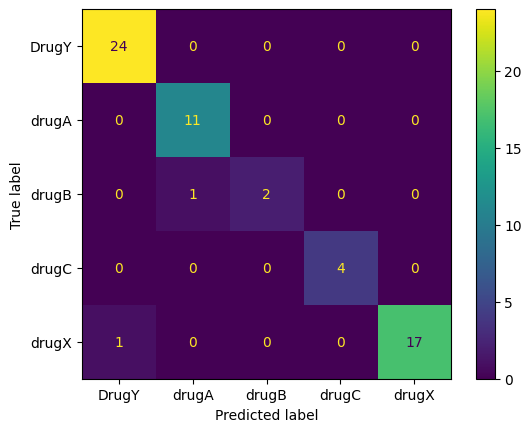

In [21]:
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, predictions, labels=pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot()
Path("result").mkdir(parents=True, exist_ok=True)
plt.savefig("result/model_results.png", dpi=120, bbox_inches="tight")

In [33]:
import importlib
import importlib.util
from pathlib import Path

Path("model").mkdir(parents=True, exist_ok=True)

if importlib.util.find_spec("skops") is not None:
    sio = importlib.import_module("skops.io")
    sio.dump(pipe, "model/drug_pipeline.skops")
else:
    from joblib import dump
    dump(pipe, "model/drug_pipeline.joblib")

In [34]:
import importlib
import importlib.util
from pathlib import Path

model_dir = Path("model")
skops_path = model_dir / "drug_pipeline.skops"
joblib_path = model_dir / "drug_pipeline.joblib"

if skops_path.exists() and importlib.util.find_spec("skops") is not None:
    sio = importlib.import_module("skops.io")
    loaded_model = sio.load(skops_path, trusted=True)
elif joblib_path.exists():
    from joblib import load
    loaded_model = load(joblib_path)
else:
    raise FileNotFoundError("No exported model found in ./model")

loaded_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('encoder', OrdinalEncoder(),
                                                  [1, 2, 3]),
                                                 ('num_imputer',
                                                  SimpleImputer(strategy='median'),
                                                  [0, 4]),
                                                 ('num_scaler',
                                                  StandardScaler(), [0, 4])])),
                ('model', RandomForestClassifier(random_state=125))])